<a href="https://colab.research.google.com/github/AlexBecerril/miaad-sem1/blob/main/275333_Sesion12_Evaluacion_Analisis_Descriptivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Edgar Alejandro Becerril Caballero
- **Matrícula:** 275333

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [37]:
df['price'].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


In [38]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.
print('Media:',df['price'].mean()) #media aritmetica o promedio (suma de todos los valores / número de valores)
print('Mediana:', df['price'].median()) #valor central de los datos ordenados de mayor a menor
print('Moda:', df['price'].mode()) #valor que ocurre con mayor frecuencia



Media: 152.7206871868289
Mediana: 106.0
Moda: 0    100
Name: price, dtype: int64


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_**Tu respuesta:**_ La media de 152.7 es aproximadamente 44% mayor que la mediana de 106, lo que representa una diferencia considerable entre ambas medidas. Esto sugiere que la distribución de price presenta una asimetría y que podrían existir valores extremos altos que estén elevando la media. Para comprobar visualmente esta distribución y la presencia de posibles valores atípicos, sería conveniente utilizar un histograma y, adicionalmente, un diagrama de caja.

---
## Actividad 2 — Dispersión (20 pts)

In [39]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.
print('Minimo: ', df['price'].min())
print('Maximo: ', df['price'].max())
print('Rango:', df['price'].max() - df['price'].min())
print('Desviación estándar:', df['price'].std())
print('Varianza:', df['price'].var())
print('Q1:', df['price'].quantile(0.25))
print('Q3:', df['price'].quantile(0.75))
print('IQR:', df['price'].quantile(0.75) - df['price'].quantile(0.25))




Minimo:  0
Maximo:  10000
Rango: 10000
Desviación estándar: 240.15416974718727
Varianza: 57674.02524696084
Q1: 69.0
Q3: 175.0
IQR: 106.0


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

**_Tu respuesta:_** El primer cuartil (Q1) es 69 y el tercer cuartil (Q3) es 175, lo que significa que el 50% central de los datos se encuentra entre estos valores. Por lo tanto, el IQR es de 106 (175 − 69). Al comparar este valor con el rango, que va aproximadamente de 0 a 10,000, se observa una gran diferencia, lo que indica la presencia de valores extremos muy altos. Por lo tanto, considero que el IQR representa mejor la dispersión típica de los datos, ya que es menos sensible a los valores atípicos que el rango.

---
## Actividad 3 — Forma (20 pts)

In [40]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
print('Asimetría:', df['price'].skew())
print('Curtosis:', df['price'].kurt())


Asimetría: 19.118938995046033
Curtosis: 585.6728788988286


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

**_Tu respuesta:_** En ambos casos la asimetría es muy marcada y positiva, lo que indica que ambas distribuciones presentan una cola hacia la derecha. Sin embargo, price presenta una asimetría considerablemente mayor que Income, con un valor de 19.12 frente a 6.76. En cuanto a la curtosis, price también presenta un valor mucho mayor, 585.67 frente a 159.6, lo que sugiere una mayor presencia de valores extremos. Por lo tanto, es esperable encontrar valores atípicos significativos en price en la siguiente etapa, los cuales deberán ser identificados y analizados.

---
## Actividad 4 — Visualización (30 pts)

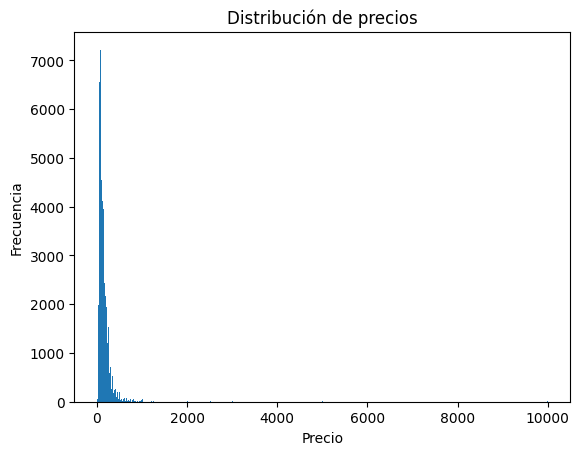

In [41]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.
# Respuesta: Elegí 500 bins para obtener una mayor resolución en la distribución de price
# y observar con mayor detalle los valores extremos.
df['price'].plot(kind='hist', bins=500, title='Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()



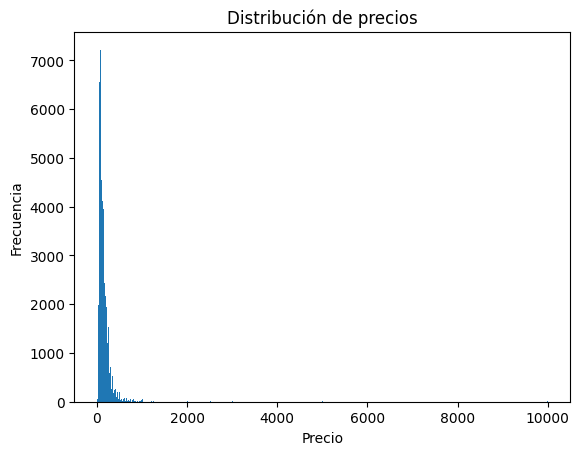

In [42]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.
plt.hist(df['price'], bins=500)
plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()



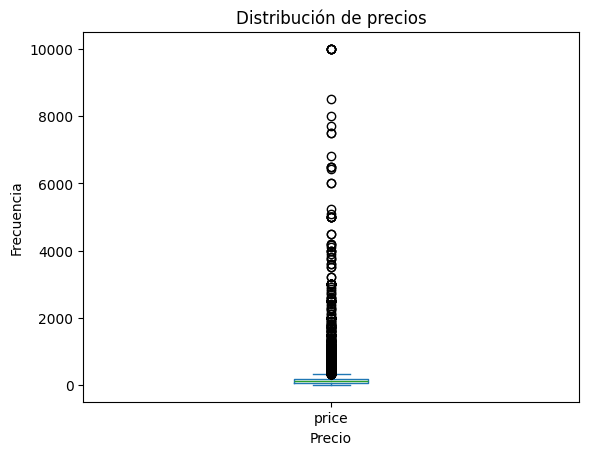

In [43]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).
df['price'].plot(kind='box', title='Precios')
plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()


**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

**_Tu respuesta:_**
* En el histograma se puede observar claramente que la mayoría de los datos se encuentran aproximadamente por debajo de 500, con una baja concentración de valores entre 500 y 1,000, algunos valores entre 2,000 y 6,000 y muy pocos entre 6,000 y 10,000. La gráfica muestra una cola muy marcada hacia la derecha, lo que indica una distribución con una fuerte asimetría positiva.
* En el caso del boxplot, se observa una caja muy estrecha, que es difícil de visualizar debido a la gran cantidad de valores extremos. Los outliers se distinguen con mayor claridad en este gráfico, mientras que en el histograma se aprecia mejor la distribución general de los datos, pero no necesariamente los valores extremos, especialmente cuando se utilizan menos bins.
* Ambas gráficas son consistentes con los valores de asimetría y curtosis calculados anteriormente. La asimetría de 19.12 se refleja en la cola muy marcada hacia la derecha observada en el histograma, mientras que la curtosis de 585.67 es consistente con la presencia de una gran cantidad de valores extremos, que se hacen más evidentes en el boxplot.

---
## Actividad 4.1 — Visualización con datos filtrados

Como análisis adicional, decidí visualizar nuevamente la variable price excluyendo temporalmente los valores superiores a 500. El objetivo es observar con mayor claridad la distribución de la mayoría de los datos y comparar cómo cambian las medidas de asimetría y curtosis al eliminar los valores extremos.

In [44]:
#Dataframe filtrando todos los valores de price menores de 500
df_filtrado = df[df['price'] < 500]

In [45]:
#Visualización de metricas clave de distribución para el dataframe filtrado
print('Minimo: ', df_filtrado['price'].min())
print('Maximo: ', df_filtrado['price'].max())
print('Rango:', df_filtrado['price'].max() - df_filtrado['price'].min())
print('Desviación estándar:', df_filtrado['price'].std())
print('Varianza:', df_filtrado['price'].var())
print('Q1:', df_filtrado['price'].quantile(0.25))
print('Q3:', df_filtrado['price'].quantile(0.75))
print('IQR:', df_filtrado['price'].quantile(0.75) - df_filtrado['price'].quantile(0.25))

Minimo:  0
Maximo:  499
Rango: 499
Desviación estándar: 85.08768408632713
Varianza: 7239.913983174607
Q1: 68.0
Q3: 170.0
IQR: 102.0


In [46]:
#Calculo de asimetria y curtosis para el dataframe filtrado
print('Asimetría:', df_filtrado['price'].skew())
print('Curtosis:', df_filtrado['price'].kurt())

Asimetría: 1.4602870894198268
Curtosis: 2.285419991812989


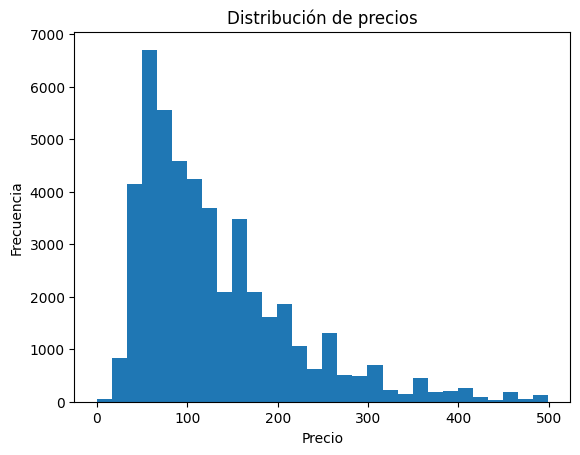

In [47]:
#Visualización de la distribución de los datos usando un histograma para el dataframe filtrado
df_filtrado['price'].plot(kind='hist', bins=30, title='Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

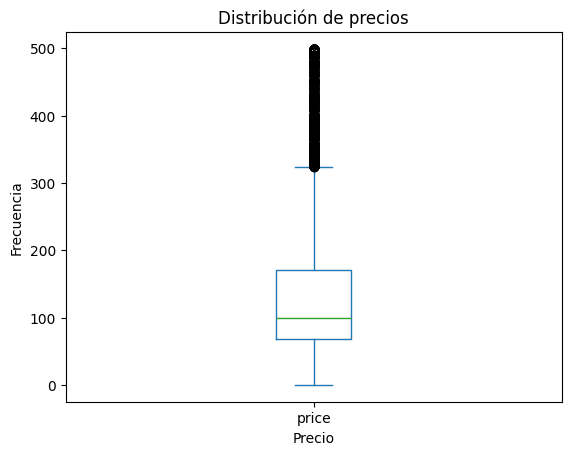

In [48]:
#Visualización de la distribución de los datos usando un boxplot para el dataframe filtrado
df_filtrado['price'].plot(kind='box', title='Precios')
plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

**Conclusión:** Excluyendo los valores extremos podemos notar inmediatamente algunas diferencias:
* La asimetría se redujo a 1.4, lo cual indica que todavía existe una asimetría positiva y una cola hacia el lado derecho, pero mucho menos extrema que en la distribución original.
* La curtosis se redujo a 2.28, lo cual indica que la distribución todavía presenta colas relativamente pesadas y algunos valores extremos, aunque en menor magnitud que en la distribución original.
* En el histograma se puede apreciar mucho mejor la distribución de los datos sin que los valores extremos compriman visualmente la mayor parte de las observaciones.
* En el boxplot podemos observar con mayor claridad dónde se encuentra la mediana, la distribución del 50% central de los datos y los bigotes. También se puede observar que todavía existen varios valores que el criterio del boxplot identifica como valores atípicos.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

**_Tu respuesta:_** El precio promedio de 152.72 puede ser engañoso, ya que está siendo influenciado por algunos valores extremadamente altos. Esto se puede observar al compararlo con la mediana, que es de 106, existe una diferencia considerable entre ambas medidas, lo que indica que una parte de los valores altos está elevando la media.

Además, la asimetría de 19.12 indica una distribución fuertemente marcada hacia la derecha, mientras que la curtosis de 585.67 sugiere la presencia valores extremos. Por lo tanto, decir que el precio promedio es de 152.72 no representa necesariamente el precio típico de la mayoría de los registros. La mediana de 106 resulta más representativa del valor central de los datos en este caso.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |